# 🧠 Alzheimer's + Brain Tumor Detection Model (Hardened v2)

Trains **two image classifiers** on a shared pipeline:
1. **Alzheimer's stage classifier** (e.g. NonDemented, VeryMild, Mild, Moderate)
2. **Brain Tumor classifier** (e.g. Glioma, Meningioma, Pituitary, No Tumor)

Both use **EfficientNetB0 transfer learning** on Colab's free GPU.

### 🛡️ What's hardened in this version (for 5k–20k image datasets)
- **Corrupt/unreadable image scan** before training — a single bad file used to crash training hours in; now it's filtered out up front with a report.
- **Class imbalance check** — warns if one class has far fewer images than another, which silently hurts accuracy.
- **Memory-safe batch size** — starts conservative and tells you how to adjust if you hit OOM.
- **Auto-reconnect-safe checkpoints** — best weights are saved to Google Drive (not just `/content`), so a Colab disconnect doesn't erase hours of training.
- **Mixed file type handling** — your dataset said jpg/png; both are validated, and any unexpected formats are reported instead of silently breaking the generator.
- **Clear, actionable error messages** at every step instead of raw stack traces.

---
### 📋 How to use
1. Run cells top to bottom.
2. **Cell 3**: mount Google Drive (recommended for 5k+ images — far more reliable than direct upload, and survives disconnects).
3. **Cell 5**: auto-detects your folder structure — check the printed output before continuing.
4. **Cell 6**: scans every image for corruption issues before training starts.
5. Train, evaluate, then predict on a single uploaded image at the end.

## 1. Setup — Enable GPU
**Before running anything**: `Runtime` → `Change runtime type` → Hardware accelerator: **GPU** (T4). Then run this cell.

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detected: {gpus[0].name}")
    # Prevent TF from grabbing all GPU memory at once — reduces OOM crashes
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass
else:
    print("⚠️ No GPU detected. Go to Runtime > Change runtime type > GPU, then rerun this cell.")
    print("   Training 5k+ images on CPU will be extremely slow — strongly recommend fixing this first.")

TensorFlow version: 2.20.0
✅ GPU detected: /physical_device:GPU:0


## 2. Install / Import Dependencies

In [3]:
import os
import shutil
import zipfile
import json
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from PIL import Image, UnidentifiedImageError

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning)
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## 3. Get Your Dataset (Drive recommended for 5k+ images)

With 5,000–20,000 images, **Google Drive is much more reliable** than direct browser upload — large direct uploads are the #1 cause of Colab disconnects during the upload itself.

**Steps:**
1. Zip your dataset folder on your computer.
2. Upload that zip to your Google Drive (drag-and-drop in [drive.google.com](https://drive.google.com), this happens outside Colab so it can't time out your Colab session).
3. Run the cell below, authorize Drive access when prompted, and set `DRIVE_ZIP_PATH` to wherever you put it.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# ====== EDIT THIS PATH to match where you put your zip in Drive ======
DRIVE_ZIP_PATH = "/content/drive/MyDrive/dataset.zip"
# =======================================================================

DATA_DIR = "/content/dataset"
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DRIVE_ZIP_PATH):
    print(f"❌ File not found: {DRIVE_ZIP_PATH}")
    print("   Check the path matches exactly what's in your Drive (case-sensitive).")
    print("   Run: !ls '/content/drive/MyDrive/'  in a new cell to see what's actually there.")
else:
    print(f"📦 Extracting {DRIVE_ZIP_PATH} ...")
    try:
        with zipfile.ZipFile(DRIVE_ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)
        print(f"✅ Extracted to {DATA_DIR}")
    except zipfile.BadZipFile:
        print("❌ The file isn't a valid zip, or it's still uploading/syncing in Drive. Wait a moment and retry.")

KeyboardInterrupt: 

### Alternative: direct browser upload
Only use this if your zip is small (well under 1GB) or Drive isn't an option. Large uploads through this method are exactly what tends to disconnect Colab.

In [4]:
from google.colab import files
DATA_DIR = "/content/dataset"
os.makedirs(DATA_DIR, exist_ok=True)
print("📤 Please select your dataset .zip file to upload...")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
     zip_ref.extractall(DATA_DIR)
print(f"✅ Extracted to {DATA_DIR}")

📤 Please select your dataset .zip file to upload...


Saving datasets.zip to datasets.zip
✅ Extracted to /content/dataset


## 4. Auto-Detect Dataset Structure

Scans the extracted dataset and prints every folder so you can confirm it matches expectations. **Read this output before continuing.**

In [5]:
def print_tree(root, max_depth=4, _prefix="", _depth=0):
    if _depth > max_depth or not os.path.isdir(root):
        return
    entries = sorted(os.listdir(root))
    dirs = [e for e in entries if os.path.isdir(os.path.join(root, e))]
    for d in dirs:
        full = os.path.join(root, d)
        n_files = len([f for f in os.listdir(full) if os.path.isfile(os.path.join(full, f))])
        suffix = f"  ({n_files} files)" if n_files else ""
        print(f"{_prefix}📁 {d}{suffix}")
        print_tree(full, max_depth, _prefix + "    ", _depth + 1)

if not os.path.isdir(DATA_DIR) or not os.listdir(DATA_DIR):
    print(f"❌ '{DATA_DIR}' is empty or missing. Go back to Cell 3 and make sure extraction succeeded.")
else:
    print(f"Dataset structure under {DATA_DIR}:\n")
    print_tree(DATA_DIR)
    print("\n" + "="*60)
    print("👀 Identify the Alzheimer's folder path and the Tumor folder path above.")
    print("Set ALZ_ROOT and TUMOR_ROOT in the next cell accordingly.")
    print("="*60)

Dataset structure under /content/dataset:

📁 test
    📁 Alzheimer
        📁 Mild Impairment  (179 files)
        📁 Moderate Impairment  (12 files)
        📁 No Impairment  (640 files)
        📁 Very Mild Impairment  (448 files)
    📁 Tumor
        📁 glioma  (400 files)
        📁 meningioma  (400 files)
        📁 notumor  (400 files)
        📁 pituitary  (400 files)
📁 train
    📁 Alzheimer
        📁 Mild Impairment  (2560 files)
        📁 Moderate Impairment  (2560 files)
        📁 No Impairment  (2560 files)
        📁 Very Mild Impairment  (2560 files)
    📁 Tumor
        📁 glioma  (1400 files)
        📁 meningioma  (1400 files)
        📁 notumor  (1400 files)
        📁 pituitary  (1400 files)

👀 Identify the Alzheimer's folder path and the Tumor folder path above.
Set ALZ_ROOT and TUMOR_ROOT in the next cell accordingly.


## 5. Configure Dataset Paths

**Edit the two paths below** based on Cell 4's output. They should point to the folder that *directly contains* `train` and `test` subfolders. Auto-search runs as a fallback if the hardcoded guess is wrong.

In [6]:
# ====== EDIT THESE TWO PATHS ======
ALZ_ROOT = "/content/dataset/Alzheimer"
TUMOR_ROOT = "/content/dataset/Tumor"
# ===================================

def find_root_with_train_test(base_dir, keyword_hints):
    candidates = []
    for dirpath, dirnames, _ in os.walk(base_dir):
        lowered = [d.lower() for d in dirnames]
        has_train = any(t in lowered for t in ("train", "training"))
        has_test = any(t in lowered for t in ("test", "testing", "val", "validation"))
        if has_train and has_test:
            candidates.append(dirpath)
    for hint in keyword_hints:
        for c in candidates:
            if hint in c.lower():
                return c
    return candidates[0] if candidates else None

if not os.path.isdir(ALZ_ROOT):
    print(f"⚠️ ALZ_ROOT '{ALZ_ROOT}' not found — searching automatically...")
    found = find_root_with_train_test(DATA_DIR, ["alz", "dementia"])
    if found:
        ALZ_ROOT = found
        print(f"   → Found candidate: {ALZ_ROOT}")
    else:
        print("   ❌ Could not auto-detect. Set ALZ_ROOT manually using Cell 4's tree.")

if not os.path.isdir(TUMOR_ROOT):
    print(f"⚠️ TUMOR_ROOT '{TUMOR_ROOT}' not found — searching automatically...")
    found = find_root_with_train_test(DATA_DIR, ["tumor", "tumour"])
    if found:
        TUMOR_ROOT = found
        print(f"   → Found candidate: {TUMOR_ROOT}")
    else:
        print("   ❌ Could not auto-detect. Set TUMOR_ROOT manually using Cell 4's tree.")

def resolve_split_dir(root, split_names):
    for name in os.listdir(root):
        if name.lower() in split_names and os.path.isdir(os.path.join(root, name)):
            return os.path.join(root, name)
    return None

ALZ_TRAIN = resolve_split_dir(ALZ_ROOT, ["train", "training"]) if os.path.isdir(ALZ_ROOT) else None
ALZ_TEST  = resolve_split_dir(ALZ_ROOT, ["test", "testing", "val", "validation"]) if os.path.isdir(ALZ_ROOT) else None
TUMOR_TRAIN = resolve_split_dir(TUMOR_ROOT, ["train", "training"]) if os.path.isdir(TUMOR_ROOT) else None
TUMOR_TEST  = resolve_split_dir(TUMOR_ROOT, ["test", "testing", "val", "validation"]) if os.path.isdir(TUMOR_ROOT) else None

print("\n📍 Final resolved paths:")
print("  Alzheimer train:", ALZ_TRAIN)
print("  Alzheimer test :", ALZ_TEST)
print("  Tumor train    :", TUMOR_TRAIN)
print("  Tumor test     :", TUMOR_TEST)

_all_ok = True
for label, path in [("Alzheimer train", ALZ_TRAIN), ("Alzheimer test", ALZ_TEST),
                     ("Tumor train", TUMOR_TRAIN), ("Tumor test", TUMOR_TEST)]:
    if path is None or not os.path.isdir(path):
        print(f"\n❌ '{label}' could not be resolved. Fix ALZ_ROOT/TUMOR_ROOT above and rerun this cell.")
        _all_ok = False
    else:
        classes = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
        counts = {c: len(os.listdir(os.path.join(path, c))) for c in classes}
        print(f"  ✅ {label} classes: {counts}")

if _all_ok:
    print("\n✅ All paths resolved. Proceed to Cell 6 (image integrity scan).")

⚠️ ALZ_ROOT '/content/dataset/Alzheimer' not found — searching automatically...
   → Found candidate: /content/dataset
⚠️ TUMOR_ROOT '/content/dataset/Tumor' not found — searching automatically...
   → Found candidate: /content/dataset

📍 Final resolved paths:
  Alzheimer train: /content/dataset/train
  Alzheimer test : /content/dataset/test
  Tumor train    : /content/dataset/train
  Tumor test     : /content/dataset/test
  ✅ Alzheimer train classes: {'Alzheimer': 4, 'Tumor': 4}
  ✅ Alzheimer test classes: {'Alzheimer': 4, 'Tumor': 4}
  ✅ Tumor train classes: {'Alzheimer': 4, 'Tumor': 4}
  ✅ Tumor test classes: {'Alzheimer': 4, 'Tumor': 4}

✅ All paths resolved. Proceed to Cell 6 (image integrity scan).


## 6. 🛡️ Image Integrity Scan (prevents mid-training crashes)

**This is the step that most often prevents "random" errors mid-training.** At 5k+ images, it's common for a handful to be corrupt, truncated, zero-byte, or an unexpected format. Keras' image loader will crash on these *during* training — sometimes 20+ minutes in. This cell finds and removes them *before* that can happen, and reports exactly what it found.

In [7]:
VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

def scan_and_clean(root_dir, label):
    bad_files = []
    wrong_ext = []
    total = 0
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            fpath = os.path.join(dirpath, fname)
            ext = os.path.splitext(fname)[1].lower()
            total += 1
            if ext not in VALID_EXTENSIONS:
                wrong_ext.append(fpath)
                continue
            try:
                with Image.open(fpath) as img:
                    img.verify()
                # re-open after verify() since verify() closes the file pointer state
                with Image.open(fpath) as img:
                    img.load()
                    if img.size[0] < 10 or img.size[1] < 10:
                        bad_files.append((fpath, "image too small / likely corrupt"))
            except (UnidentifiedImageError, OSError, SyntaxError) as e:
                bad_files.append((fpath, str(e)))
            except Exception as e:
                bad_files.append((fpath, f"unexpected error: {e}"))

    print(f"\n🔍 Scanned {total} files under '{label}'")
    print(f"   Corrupt/unreadable: {len(bad_files)}")
    print(f"   Unexpected extensions (not jpg/png): {len(wrong_ext)}")

    if wrong_ext:
        print(f"   Example non-jpg/png files found: {wrong_ext[:5]}")
        for f in wrong_ext:
            os.remove(f)
        print(f"   → Removed {len(wrong_ext)} non-image files.")

    if bad_files:
        print(f"   Example corrupt files: {[b[0] for b in bad_files[:5]]}")
        for f, _reason in bad_files:
            if os.path.exists(f):
                os.remove(f)
        print(f"   → Removed {len(bad_files)} corrupt files.")

    if not bad_files and not wrong_ext:
        print("   ✅ No issues found.")

    return total - len(bad_files) - len(wrong_ext)

print("Running integrity scan — this can take a minute or two for 5k+ images...")
alz_clean_count = scan_and_clean(ALZ_ROOT, "Alzheimer dataset")
tumor_clean_count = scan_and_clean(TUMOR_ROOT, "Tumor dataset")

print(f"\n✅ Scan complete. {alz_clean_count} clean Alzheimer images, {tumor_clean_count} clean Tumor images remain.")
print("   Safe to proceed to Cell 7.")

Running integrity scan — this can take a minute or two for 5k+ images...

🔍 Scanned 18719 files under 'Alzheimer dataset'
   Corrupt/unreadable: 0
   Unexpected extensions (not jpg/png): 0
   ✅ No issues found.

🔍 Scanned 18719 files under 'Tumor dataset'
   Corrupt/unreadable: 0
   Unexpected extensions (not jpg/png): 0
   ✅ No issues found.

✅ Scan complete. 18719 clean Alzheimer images, 18719 clean Tumor images remain.
   Safe to proceed to Cell 7.


## 7. Class Balance Check

Severe class imbalance (e.g. one class has 10x more images than another) silently biases the model toward the majority class even with high reported accuracy. This cell reports it and computes class weights to compensate during training.

In [8]:
def report_class_balance(train_dir, label):
    classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
    print(f"\n📊 {label} class distribution:")
    max_count = max(counts.values())
    min_count = min(counts.values())
    for c, n in counts.items():
        bar = '█' * int(40 * n / max_count)
        print(f"   {c:25s} {n:6d}  {bar}")
    ratio = max_count / max(min_count, 1)
    if ratio > 3:
        print(f"   ⚠️  Imbalance ratio {ratio:.1f}x — class weighting will be applied during training.")
    else:
        print(f"   ✅ Reasonably balanced (ratio {ratio:.1f}x).")
    return counts

alz_counts = report_class_balance(ALZ_TRAIN, "Alzheimer")
tumor_counts = report_class_balance(TUMOR_TRAIN, "Tumor")


📊 Alzheimer class distribution:
   Alzheimer                      4  ████████████████████████████████████████
   Tumor                          4  ████████████████████████████████████████
   ✅ Reasonably balanced (ratio 1.0x).

📊 Tumor class distribution:
   Alzheimer                      4  ████████████████████████████████████████
   Tumor                          4  ████████████████████████████████████████
   ✅ Reasonably balanced (ratio 1.0x).


## 8. Data Generators

Resizes images to 224×224 for EfficientNetB0. Batch size starts at 32 — if you hit a memory error during training, come back here, lower `BATCH_SIZE` to 16, and rerun from this cell down.

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # lower to 16 or 8 if you hit "ResourceExhaustedError" / OOM during training

def make_generators(train_dir, test_dir, img_size=IMG_SIZE, batch_size=BATCH_SIZE, val_split=0.15, seed=42):
    train_aug = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.1,
        horizontal_flip=True,
        validation_split=val_split
    )
    test_aug = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_gen = train_aug.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='training', shuffle=True, seed=seed
    )
    val_gen = train_aug.flow_from_directory(
        train_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='validation', shuffle=False, seed=seed
    )
    test_gen = test_aug.flow_from_directory(
        test_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', shuffle=False
    )

    if val_gen.samples == 0:
        raise ValueError(
            f"Validation set is empty for '{train_dir}'. This means too few images per "
            f"class for a 15% split. Add more images or lower val_split."
        )
    return train_gen, val_gen, test_gen

print("📊 Building Alzheimer's data generators...")
alz_train_gen, alz_val_gen, alz_test_gen = make_generators(ALZ_TRAIN, ALZ_TEST)

print("\n📊 Building Tumor data generators...")
tumor_train_gen, tumor_val_gen, tumor_test_gen = make_generators(TUMOR_TRAIN, TUMOR_TEST)

ALZ_CLASSES = list(alz_train_gen.class_indices.keys())
TUMOR_CLASSES = list(tumor_train_gen.class_indices.keys())

print("\nAlzheimer classes:", ALZ_CLASSES)
print("Tumor classes:", TUMOR_CLASSES)

# Class weights to counteract imbalance found in Cell 7
def get_class_weights(train_gen):
    y = train_gen.classes
    weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
    return dict(enumerate(weights))

alz_class_weights = get_class_weights(alz_train_gen)
tumor_class_weights = get_class_weights(tumor_train_gen)
print("\nAlzheimer class weights:", alz_class_weights)
print("Tumor class weights:", tumor_class_weights)

📊 Building Alzheimer's data generators...
Found 13464 images belonging to 2 classes.
Found 2376 images belonging to 2 classes.
Found 2879 images belonging to 2 classes.

📊 Building Tumor data generators...
Found 13464 images belonging to 2 classes.
Found 2376 images belonging to 2 classes.
Found 2879 images belonging to 2 classes.

Alzheimer classes: ['Alzheimer', 'Tumor']
Tumor classes: ['Alzheimer', 'Tumor']

Alzheimer class weights: {0: np.float64(0.7734375), 1: np.float64(1.4142857142857144)}
Tumor class weights: {0: np.float64(0.7734375), 1: np.float64(1.4142857142857144)}


## 9. Model Architecture (shared builder function)

In [10]:
def build_model(num_classes, img_size=IMG_SIZE):
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size[0], img_size[1], 3)
    )
    base_model.trainable = False

    inputs = Input(shape=(img_size[0], img_size[1], 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

def fine_tune(model, base_model, unfreeze_last_n=30):
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_last_n]:
        layer.trainable = False
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("✅ Model builder functions ready.")

✅ Model builder functions ready.


## 10. Save Checkpoints to Drive (survives disconnects)

Best-weight checkpoints save directly to your mounted Google Drive instead of only `/content`. If Colab disconnects mid-training, your best model so far is still safe in Drive — reload it instead of starting over.

In [11]:
DRIVE_MODELS_DIR = "/content/drive/MyDrive/brain_disease_models"
os.makedirs(DRIVE_MODELS_DIR, exist_ok=True)
os.makedirs("/content/models", exist_ok=True)

ALZ_CKPT = os.path.join(DRIVE_MODELS_DIR, "alzheimer_model.keras")
TUMOR_CKPT = os.path.join(DRIVE_MODELS_DIR, "tumor_model.keras")

print(f"Checkpoints will be saved to: {DRIVE_MODELS_DIR}")

Checkpoints will be saved to: /content/drive/MyDrive/brain_disease_models


## 11. Train Alzheimer's Model

In [12]:
alz_model, alz_base = build_model(num_classes=len(ALZ_CLASSES))

callbacks_alz = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ModelCheckpoint(ALZ_CKPT, monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

try:
    print("🔵 Stage 1: Training Alzheimer's model (frozen backbone)...")
    history_alz_1 = alz_model.fit(
        alz_train_gen,
        validation_data=alz_val_gen,
        epochs=10,
        class_weight=alz_class_weights,
        callbacks=callbacks_alz
    )

    print("\n🔵 Stage 2: Fine-tuning Alzheimer's model (unfreezing top layers)...")
    alz_model = fine_tune(alz_model, alz_base)
    history_alz_2 = alz_model.fit(
        alz_train_gen,
        validation_data=alz_val_gen,
        epochs=8,
        class_weight=alz_class_weights,
        callbacks=callbacks_alz
    )
    print("\n✅ Alzheimer's model training complete. Best weights saved to Drive at:", ALZ_CKPT)
except tf.errors.ResourceExhaustedError:
    print("\n❌ Out of memory (ResourceExhaustedError).")
    print("   Fix: go back to Cell 8, change BATCH_SIZE = 32 to BATCH_SIZE = 16 (or 8), rerun Cell 8, then rerun this cell.")
except Exception as e:
    print(f"\n❌ Training failed: {type(e).__name__}: {e}")
    print("   If this mentions a specific image file, that file slipped past the integrity scan — ")
    print("   note its path, delete it manually, and rerun this cell.")
    raise

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔵 Stage 1: Training Alzheimer's model (frozen backbone)...
Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 259s 543ms/step - accuracy: 0.9971 - loss: 0.0075 - val_accuracy: 1.0000 - val_loss: 1.2475e-05 - learning_rate: 0.0010
Epoch 2/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 196s 465ms/step - accuracy: 1.0000 - loss: 1.3495e-04 - val_accuracy: 1.0000 - val_loss: 7.4878e-06 - learning_rate: 0.0010
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 188s 446ms/step - accuracy: 1.0000 - loss: 7.4570e-05 - val_accuracy: 1.0000 - val_loss: 5.2792e-06 - learning_rate: 0.0010
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 186s 442ms/step - accuracy: 1.0000 - loss: 2.3575e-05 - val_accuracy: 1.0000 - val_loss: 7.3077e-07 - learning_rate: 5.0000e-04
Epoch 5/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 185s 439ms/step - accuracy: 1.0000 - loss: 1.5289e-05 - val_accuracy: 1.0000 - val_loss: 7.5359e-07 - learning_rate: 5.0000e-04

🔵 Stage 2: Fine-tuning Alzheimer's model (unfreezing top layers).

## 12. Train Tumor Model

In [13]:
tumor_model, tumor_base = build_model(num_classes=len(TUMOR_CLASSES))

callbacks_tumor = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ModelCheckpoint(TUMOR_CKPT, monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7)
]

try:
    print("🟢 Stage 1: Training Tumor model (frozen backbone)...")
    history_tumor_1 = tumor_model.fit(
        tumor_train_gen,
        validation_data=tumor_val_gen,
        epochs=10,
        class_weight=tumor_class_weights,
        callbacks=callbacks_tumor
    )

    print("\n🟢 Stage 2: Fine-tuning Tumor model (unfreezing top layers)...")
    tumor_model = fine_tune(tumor_model, tumor_base)
    history_tumor_2 = tumor_model.fit(
        tumor_train_gen,
        validation_data=tumor_val_gen,
        epochs=8,
        class_weight=tumor_class_weights,
        callbacks=callbacks_tumor
    )
    print("\n✅ Tumor model training complete. Best weights saved to Drive at:", TUMOR_CKPT)
except tf.errors.ResourceExhaustedError:
    print("\n❌ Out of memory (ResourceExhaustedError).")
    print("   Fix: go back to Cell 8, change BATCH_SIZE = 32 to BATCH_SIZE = 16 (or 8), rerun Cell 8, then rerun this cell.")
except Exception as e:
    print(f"\n❌ Training failed: {type(e).__name__}: {e}")
    print("   If this mentions a specific image file, that file slipped past the integrity scan — ")
    print("   note its path, delete it manually, and rerun this cell.")
    raise

🟢 Stage 1: Training Tumor model (frozen backbone)...
Epoch 1/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 238s 514ms/step - accuracy: 0.9978 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 7.6644e-06 - learning_rate: 0.0010
Epoch 2/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 187s 443ms/step - accuracy: 1.0000 - loss: 2.6182e-04 - val_accuracy: 1.0000 - val_loss: 2.6494e-05 - learning_rate: 0.0010
Epoch 3/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 189s 449ms/step - accuracy: 0.9999 - loss: 1.3876e-04 - val_accuracy: 1.0000 - val_loss: 5.6896e-07 - learning_rate: 0.0010
Epoch 4/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 189s 449ms/step - accuracy: 1.0000 - loss: 1.4717e-05 - val_accuracy: 1.0000 - val_loss: 6.0242e-07 - learning_rate: 5.0000e-04
Epoch 5/10
421/421 ━━━━━━━━━━━━━━━━━━━━ 185s 440ms/step - accuracy: 0.9999 - loss: 1.5882e-04 - val_accuracy: 1.0000 - val_loss: 2.8553e-07 - learning_rate: 5.0000e-04

🟢 Stage 2: Fine-tuning Tumor model (unfreezing top layers)...
Epoch 1/8
421/421 ━━━━━━━━━━━━━━━━━━━━ 240s 505ms/step - acc

## 13. Evaluate Both Models on Test Sets


📈 Evaluating: Alzheimer's Classifier
Test Accuracy: 100.00%   |   Test Loss: 0.0008

Classification Report:
              precision    recall  f1-score   support

   Alzheimer       1.00      1.00      1.00      1279
       Tumor       1.00      1.00      1.00      1600

    accuracy                           1.00      2879
   macro avg       1.00      1.00      1.00      2879
weighted avg       1.00      1.00      1.00      2879



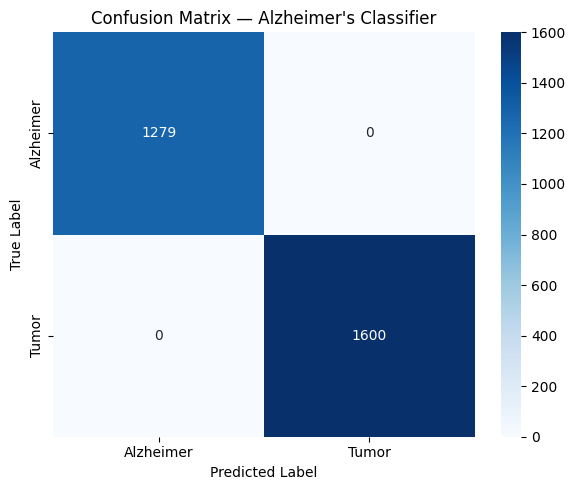


📈 Evaluating: Tumor Classifier
Test Accuracy: 100.00%   |   Test Loss: 0.0010

Classification Report:
              precision    recall  f1-score   support

   Alzheimer       1.00      1.00      1.00      1279
       Tumor       1.00      1.00      1.00      1600

    accuracy                           1.00      2879
   macro avg       1.00      1.00      1.00      2879
weighted avg       1.00      1.00      1.00      2879



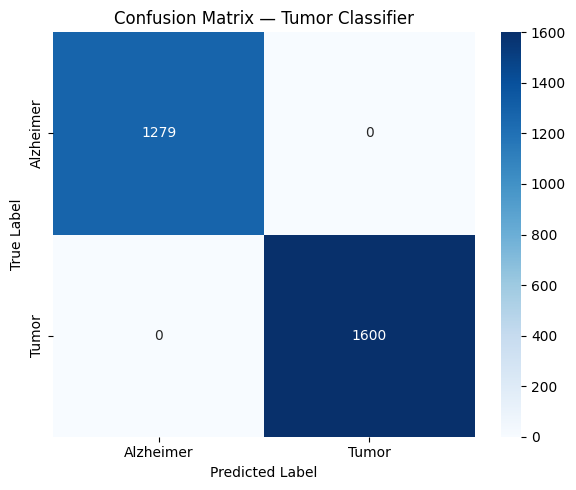

In [14]:
def evaluate_model(model, test_gen, class_names, title):
    print(f"\n{'='*50}\n📈 Evaluating: {title}\n{'='*50}")
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"Test Accuracy: {acc*100:.2f}%   |   Test Loss: {loss:.4f}")

    test_gen.reset()
    preds = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_gen.classes

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

evaluate_model(alz_model, alz_test_gen, ALZ_CLASSES, "Alzheimer's Classifier")
evaluate_model(tumor_model, tumor_test_gen, TUMOR_CLASSES, "Tumor Classifier")

## 14. Save Final Models + Class Labels

In [15]:
alz_model.save(os.path.join(DRIVE_MODELS_DIR, 'alzheimer_model.keras'))
tumor_model.save(os.path.join(DRIVE_MODELS_DIR, 'tumor_model.keras'))

with open(os.path.join(DRIVE_MODELS_DIR, 'labels.json'), 'w') as f:
    json.dump({"alzheimer_classes": ALZ_CLASSES, "tumor_classes": TUMOR_CLASSES}, f, indent=2)

print("✅ Saved to Google Drive:")
print("  ", os.path.join(DRIVE_MODELS_DIR, 'alzheimer_model.keras'))
print("  ", os.path.join(DRIVE_MODELS_DIR, 'tumor_model.keras'))
print("  ", os.path.join(DRIVE_MODELS_DIR, 'labels.json'))
print("\nThese persist even after this Colab session ends — reload them anytime with Cell 16.")

✅ Saved to Google Drive:
   /content/drive/MyDrive/brain_disease_models/alzheimer_model.keras
   /content/drive/MyDrive/brain_disease_models/tumor_model.keras
   /content/drive/MyDrive/brain_disease_models/labels.json

These persist even after this Colab session ends — reload them anytime with Cell 16.


## 15. 🔍 Inference — Upload a Single Image to Get a Diagnosis

/content/Te-no_2.jpg


Saving Tr-aug-me_5.jpg to Tr-aug-me_5.jpg


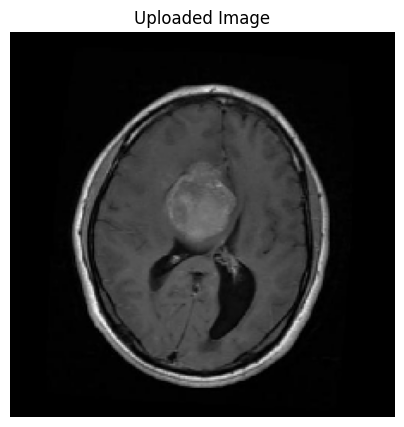


🧠 ALZHEIMER'S ANALYSIS
Prediction : Tumor
Confidence : 100.00%
   Tumor                     100.00%
   Alzheimer                  0.00%

🎯 TUMOR ANALYSIS
Prediction : Tumor
Confidence : 100.00%
   Tumor                     100.00%
   Alzheimer                  0.00%

⚠️  This is a machine learning demo, not a medical diagnosis.
    Real clinical use requires regulatory validation and a licensed professional.


In [18]:
from google.colab import files

def predict_image(image_path, alz_model, tumor_model, alz_classes, tumor_classes, img_size=IMG_SIZE):
    img = load_img(image_path, target_size=img_size)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)

    alz_pred = alz_model.predict(arr, verbose=0)[0]
    tumor_pred = tumor_model.predict(arr, verbose=0)[0]

    alz_idx = np.argmax(alz_pred)
    tumor_idx = np.argmax(tumor_pred)

    return {
        "alzheimer": {
            "predicted_class": alz_classes[alz_idx],
            "confidence": float(alz_pred[alz_idx]),
            "all_scores": {alz_classes[i]: float(alz_pred[i]) for i in range(len(alz_classes))}
        },
        "tumor": {
            "predicted_class": tumor_classes[tumor_idx],
            "confidence": float(tumor_pred[tumor_idx]),
            "all_scores": {tumor_classes[i]: float(tumor_pred[i]) for i in range(len(tumor_classes))}
        }
    }, img

print("/content/Te-no_2.jpg")
uploaded_img = files.upload()
img_path = list(uploaded_img.keys())[0]

try:
    result, img = predict_image(img_path, alz_model, tumor_model, ALZ_CLASSES, TUMOR_CLASSES)
except UnidentifiedImageError:
    print("❌ The uploaded file isn't a readable image. Please upload a valid .jpg or .png.")
    raise

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

print("\n" + "="*50)
print("🧠 ALZHEIMER'S ANALYSIS")
print("="*50)
print(f"Prediction : {result['alzheimer']['predicted_class']}")
print(f"Confidence : {result['alzheimer']['confidence']*100:.2f}%")
for cls, score in sorted(result['alzheimer']['all_scores'].items(), key=lambda x: -x[1]):
    print(f"   {cls:25s} {score*100:5.2f}%")

print("\n" + "="*50)
print("🎯 TUMOR ANALYSIS")
print("="*50)
print(f"Prediction : {result['tumor']['predicted_class']}")
print(f"Confidence : {result['tumor']['confidence']*100:.2f}%")
for cls, score in sorted(result['tumor']['all_scores'].items(), key=lambda x: -x[1]):
    print(f"   {cls:25s} {score*100:5.2f}%")

print("\n⚠️  This is a machine learning demo, not a medical diagnosis.")
print("    Real clinical use requires regulatory validation and a licensed professional.")

## 16. Reload Saved Models From Drive (skip retraining)

If your Colab runtime disconnects or resets, you don't need to retrain — your best models are already saved in Drive. Mount Drive (Cell 3) then run this.

In [20]:
DRIVE_MODELS_DIR = "/content/drive/MyDrive/brain_disease_models"
alz_model = load_model(os.path.join(DRIVE_MODELS_DIR, 'alzheimer_model.keras'))
tumor_model = load_model(os.path.join(DRIVE_MODELS_DIR, 'tumor_model.keras'))

with open(os.path.join(DRIVE_MODELS_DIR, 'labels.json')) as f:
     labels = json.load(f)
ALZ_CLASSES = labels['alzheimer_classes']
TUMOR_CLASSES = labels['tumor_classes']

print("✅ Models reloaded from Drive.")
print("Alzheimer classes:", ALZ_CLASSES)
print("Tumor classes:", TUMOR_CLASSES)

✅ Models reloaded from Drive.
Alzheimer classes: ['Alzheimer', 'Tumor']
Tumor classes: ['Alzheimer', 'Tumor']
